In [6]:
"""
Evaluate IGR and Emotion predictions from one or more CSV files.

Expected CSV columns:
  - gold_igr, predicted_igr
  - gold_emotions, predicted_emotions

Emotions are multi-label (pipe-separated, e.g. "Ang/er|Disgust").
Each emotion is evaluated independently with binary F1.

Single CSV  -> standard F1 report.
Multiple CSVs (one per run/seed) -> mean F1 (SD) matching the paper's format.
"""

import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import MultiLabelBinarizer
from collections import defaultdict
import sys
import glob


# ──────────────────────────────────────────────────────────────────────
#  The 7 emotion classes from the paper
# ──────────────────────────────────────────────────────────────────────
EMOTIONS = ["Admiration", "Anger", "Disgust", "Interest", "Joy", "Sadness", "No Emotion"]

# ──────────────────────────────────────────────────────────────────────
#  Helper: parse pipe-separated emotions into sets
# ──────────────────────────────────────────────────────────────────────
def parse_emotions(series):
    """Convert a column of pipe-separated emotion strings into list of sets."""
    # Map common variants of "no emotion" to the canonical label
    no_emotion_variants = {"", "nan", "none", "no emotion", "no_emotion", "neutral"}

    result = []
    for val in series:
        val = str(val).strip()
        if val.lower() in no_emotion_variants:
            result.append({"No Emotion"})
        else:
            emotions = set(e.strip() for e in val.split("|") if e.strip())
            # Normalise any "no emotion" variants inside a pipe-separated string
            normalised = set()
            for e in emotions:
                if e.lower() in no_emotion_variants:
                    normalised.add("No Emotion")
                else:
                    normalised.add(e)
            result.append(normalised)
    return result


# ──────────────────────────────────────────────────────────────────────
#  Core: evaluate a single CSV
# ──────────────────────────────────────────────────────────────────────
def evaluate_single(csv_path: str) -> dict:
    """Evaluate one CSV file. Returns all metrics including per-emotion binary F1."""
    df = pd.read_csv(csv_path)

    required = {"gold_igr", "predicted_igr", "gold_emotions", "predicted_emotions"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV is missing columns: {missing}")

    for col in required:
        df[col] = df[col].astype(str).str.strip()

    # ── IGR (single-label, unchanged) ──
    igr_f1_macro = f1_score(
        df["gold_igr"], df["predicted_igr"], average="macro", zero_division=0
    )
    igr_per_class = classification_report(
        df["gold_igr"], df["predicted_igr"],
        output_dict=True, zero_division=0,
    )

    # ── Emotions (multi-label → per-emotion binary F1) ──
    gold_sets = parse_emotions(df["gold_emotions"])
    pred_sets = parse_emotions(df["predicted_emotions"])

    # Get all unique individual emotions from gold labels
    all_emotions = sorted(set(e for s in gold_sets for e in s))

    mlb = MultiLabelBinarizer(classes=all_emotions)
    gold_bin = mlb.fit_transform(gold_sets)
    pred_bin = mlb.transform(pred_sets)

    # Per-emotion binary F1
    emotion_f1 = {}
    for i, emo in enumerate(all_emotions):
        emotion_f1[emo] = f1_score(gold_bin[:, i], pred_bin[:, i], zero_division=0)

    # Macro F1 across individual emotions
    emotion_f1_macro = np.mean(list(emotion_f1.values())) if emotion_f1 else 0.0

    # ── Combined ──
    avg_f1_macro = (igr_f1_macro + emotion_f1_macro) / 2

    return {
        "igr_f1_macro": igr_f1_macro,
        "igr_per_class": igr_per_class,
        "emotion_f1_macro": emotion_f1_macro,
        "emotion_per_class": emotion_f1,       # dict: emotion_name -> f1
        "avg_f1_macro": avg_f1_macro,
        "all_emotions": all_emotions,
    }


# ──────────────────────────────────────────────────────────────────────
#  Multi-run: evaluate N CSVs -> mean (SD)
# ──────────────────────────────────────────────────────────────────────
def evaluate_multi(csv_paths: list, verbose: bool = True) -> dict:
    """Evaluate multiple run CSVs and report mean (SD)."""
    all_results = [evaluate_single(p) for p in csv_paths]
    n = len(all_results)

    # ── Scalar metrics ──
    igr_macros = [r["igr_f1_macro"] for r in all_results]
    emo_macros = [r["emotion_f1_macro"] for r in all_results]
    avg_macros = [r["avg_f1_macro"] for r in all_results]

    # ── Per-class IGR F1 ──
    igr_classes = set()
    for r in all_results:
        for k in r["igr_per_class"]:
            if k not in ("accuracy", "macro avg", "weighted avg"):
                igr_classes.add(k)
    igr_classes = sorted(igr_classes)

    igr_per_class_f1 = defaultdict(list)
    for r in all_results:
        for cls in igr_classes:
            f1 = r["igr_per_class"].get(cls, {}).get("f1-score", 0.0)
            igr_per_class_f1[cls].append(f1)

    # ── Per-emotion F1 (individual emotions only) ──
    all_emotions = set()
    for r in all_results:
        all_emotions.update(r["all_emotions"])
    all_emotions = sorted(all_emotions)

    emotion_per_class_f1 = defaultdict(list)
    for r in all_results:
        for emo in all_emotions:
            emotion_per_class_f1[emo].append(r["emotion_per_class"].get(emo, 0.0))

    # ── Format helper ──
    def fmt(values):
        arr = np.array(values) * 100
        return f"{arr.mean():.1f} ({arr.std():.1f})"

    # ── Print ──
    if verbose:
        print(f"\nResults over {n} runs")
        print(f"Files: {', '.join(csv_paths)}\n")

        print("=" * 50)
        print("IGR Prediction  (F1 x 100)")
        print("=" * 50)
        for cls in igr_classes:
            print(f"  {cls:<20s} {fmt(igr_per_class_f1[cls])}")
        print(f"  {'Macro F1':<20s} {fmt(igr_macros)}")

        print()
        print("=" * 50)
        print("Emotion Prediction  (F1 x 100, per-emotion binary)")
        print("=" * 50)
        for emo in all_emotions:
            print(f"  {emo:<20s} {fmt(emotion_per_class_f1[emo])}")
        print(f"  {'Macro F1':<20s} {fmt(emo_macros)}")

        print()
        print("=" * 50)
        print("Combined Scores")
        print("=" * 50)
        print(f"  {'Task-avg Macro F1':<20s} {fmt(avg_macros)}")

    return {
        "n_runs": n,
        "igr_f1_macro":     {"mean": np.mean(igr_macros),    "std": np.std(igr_macros)},
        "emotion_f1_macro": {"mean": np.mean(emo_macros),    "std": np.std(emo_macros)},
        "avg_f1_macro":     {"mean": np.mean(avg_macros),    "std": np.std(avg_macros)},
        "igr_per_class":    {c: {"mean": np.mean(v), "std": np.std(v)}
                             for c, v in igr_per_class_f1.items()},
        "emotion_per_class":{c: {"mean": np.mean(v), "std": np.std(v)}
                             for c, v in emotion_per_class_f1.items()},
    }


# ──────────────────────────────────────────────────────────────────────
#  Convenience wrapper
# ──────────────────────────────────────────────────────────────────────
def evaluate_csv(csv_paths, verbose: bool = True):
    """
    Accept a single path (str), list of paths, or a glob pattern.

    Examples
    --------
    evaluate_csv("run1.csv")                        # single run
    evaluate_csv(["run1.csv", "run2.csv", ...])     # multi-run list
    evaluate_csv("results/run_*.csv")               # glob pattern
    """
    if isinstance(csv_paths, str):
        expanded = sorted(glob.glob(csv_paths))
        if not expanded:
            expanded = [csv_paths]
    else:
        expanded = list(csv_paths)

    if len(expanded) == 1:
        result = evaluate_single(expanded[0])
        if verbose:
            print("=" * 50)
            print("IGR Classification Report  (F1 x 100)")
            print("=" * 50)
            for cls in sorted(result["igr_per_class"]):
                if cls in ("accuracy", "macro avg", "weighted avg"):
                    continue
                f1 = result["igr_per_class"][cls]["f1-score"] * 100
                print(f"  {cls:<20s} {f1:.1f}")
            print(f"  {'Macro F1':<20s} {result['igr_f1_macro']*100:.1f}\n")

            print("=" * 50)
            print("Emotion Prediction  (F1 x 100, per-emotion binary)")
            print("=" * 50)
            for emo in sorted(result["emotion_per_class"]):
                f1 = result["emotion_per_class"][emo] * 100
                print(f"  {emo:<20s} {f1:.1f}")
            print(f"  {'Macro F1':<20s} {result['emotion_f1_macro']*100:.1f}\n")

            print("=" * 50)
            print("Combined Scores")
            print("=" * 50)
            print(f"  Task-avg Macro F1 : {result['avg_f1_macro']*100:.1f}")
        return result
    else:
        return evaluate_multi(expanded, verbose=verbose)


In [7]:
from pathlib import Path
PROJECT_ROOT = Path("..") # since notebook is in evaluation/
 
# ── Auto-discover all *_label directories ──
label_dirs = sorted(
    d for d in PROJECT_ROOT.iterdir()
    if d.is_dir() and d.name.endswith("_label")
)
 
print(f"Found {len(label_dirs)} label directories:")
for d in label_dirs:
    print(f"  - {d.name}")
print()
 
# ── Evaluate each ──
all_results = {}
 
for label_dir in label_dirs:
    model_name = label_dir.name.replace("_label", "")
 
    # Find all CSVs in the directory
    csv_files = sorted(glob.glob(str(label_dir / "*.csv")))
 
    if not csv_files:
        print(f"⚠️  No CSVs found in {label_dir.name}, skipping.\n")
        continue
 
    print(f"\n{'#' * 60}")
    print(f"  MODEL: {model_name}  ({len(csv_files)} file(s))")
    print(f"{'#' * 60}")
 
    result = evaluate_csv(csv_files, verbose=True)
    all_results[model_name] = result
 
# ── Summary comparison table ──
print(f"\n\n{'=' * 70}")
print("SUMMARY COMPARISON ACROSS ALL MODELS")
print(f"{'=' * 70}")
print(f"  {'Model':<20s} {'IGR F1':<15s} {'Emotion F1':<15s} {'Avg F1':<15s}")
print(f"  {'-'*20} {'-'*15} {'-'*15} {'-'*15}")
 
for model_name, result in all_results.items():
    # Handle both single-run (raw floats) and multi-run (mean/std dicts)
    if isinstance(result.get("igr_f1_macro"), dict):
        igr   = f"{result['igr_f1_macro']['mean']*100:.1f} ({result['igr_f1_macro']['std']*100:.1f})"
        emo   = f"{result['emotion_f1_macro']['mean']*100:.1f} ({result['emotion_f1_macro']['std']*100:.1f})"
        avg   = f"{result['avg_f1_macro']['mean']*100:.1f} ({result['avg_f1_macro']['std']*100:.1f})"
    else:
        igr   = f"{result['igr_f1_macro']*100:.1f}"
        emo   = f"{result['emotion_f1_macro']*100:.1f}"
        avg   = f"{result['avg_f1_macro']*100:.1f}"
 
    print(f"  {model_name:<20s} {igr:<15s} {emo:<15s} {avg:<15s}")

Found 4 label directories:
  - claude_label
  - deepseek_label
  - gemini_label
  - gpt_label


############################################################
  MODEL: claude  (3 file(s))
############################################################

Results over 3 runs
Files: ../claude_label/predictions_cot_thinking.csv, ../claude_label/predictions_few_shot.csv, ../claude_label/predictions_zero_shot.csv

IGR Prediction  (F1 x 100)
  In-Group             75.0 (0.8)
  Out-Group            49.0 (3.9)
  Macro F1             62.0 (2.3)

Emotion Prediction  (F1 x 100, per-emotion binary)
  Admiration           61.7 (5.0)
  Anger                78.3 (1.9)
  Disgust              79.6 (4.2)
  Interest             28.9 (7.3)
  Joy                  83.8 (0.5)
  No Emotion           50.0 (1.6)
  Sadness              68.1 (1.0)
  Macro F1             64.4 (1.0)

Combined Scores
  Task-avg Macro F1    63.2 (0.9)

############################################################
  MODEL: deepseek  (3 file(s

/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear', 'Surprise'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear', 'Surprise'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear', 'Surprise'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear', 'Surprise'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear', 'Surprise'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909:


Results over 3 runs
Files: ../gemini_label/predictions_cot_thinking.csv, ../gemini_label/predictions_few_shot.csv, ../gemini_label/predictions_zero_shot.csv

IGR Prediction  (F1 x 100)
  In-Group             73.6 (1.2)
  Out-Group            46.2 (6.2)
  Macro F1             59.9 (3.7)

Emotion Prediction  (F1 x 100, per-emotion binary)
  Admiration           56.6 (9.8)
  Anger                85.9 (2.3)
  Disgust              65.4 (7.7)
  Interest             45.6 (3.0)
  Joy                  76.5 (0.6)
  No Emotion           33.6 (6.3)
  Sadness              66.6 (1.9)
  Macro F1             61.5 (2.8)

Combined Scores
  Task-avg Macro F1    60.7 (3.2)

############################################################
  MODEL: gpt  (3 file(s))
############################################################

Results over 3 runs
Files: ../gpt_label/predictions_cot_thinking.csv, ../gpt_label/predictions_few_shot.csv, ../gpt_label/predictions_zero_shot.csv

IGR Prediction  (F1 x 100)
  In-Group 

/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear', 'Surprise'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear', 'Surprise'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear'] will be ignored
  warnings.warn(


In [8]:
"""
CELL 1: Paper baselines + your model results
==============================================
All values from Tables 4 & 6 of the paper.
"""
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Paper baselines: IGR macro F1 ──
# From Table 4. Format: (mean, SD) — SD is None if not reported.
paper_baselines = {
    "Majority Class":   {"igr": (51.1, None),  "emo": (None, None)},
    "Sentiment-Rule":   {"igr": (56.3, None),  "emo": (None, None)},
    "NB-SVM":           {"igr": (62.5, None),  "emo": (None, None)},
    "Human":            {"igr": (66.7, None),  "emo": (None, None)},
    "Emo-Lex":          {"igr": (None, None),  "emo": (23.5, None)},   # lexicon-only, no IGR
    "BERTweet":         {"igr": (74.1, 3.3),   "emo": (55.4, None)},
    "BERTweet-ft":      {"igr": (66.5, 1.6),   "emo": (28.2, None)},
    "Multitask":        {"igr": (77.3, 0.8),   "emo": (64.7, None)},
}

# ── Paper per-emotion F1 from Table 6 ──
# Format: {model: {emotion: (mean, SD)}}
paper_per_emotion = {
    "Emo-Lex": {
        "Admiration": (37.5, None), "Anger": (26.6, None), "Disgust": (25.5, None),
        "Interest":   (0.0,  None), "Joy":   (48.4, None), "Sadness": (4.3,  None),
        "No Emotion": (22.2, None),
    },
    "BERTweet": {
        "Admiration": (70.3, 3.7),  "Anger": (71.3, 11.2), "Disgust": (47.1, 21.6),
        "Interest":   (53.1, 3.3),  "Joy":   (85.9, 1.9),  "Sadness": (11.1, 9.6),
        "No Emotion": (49.1, 1.2),
    },
    "BERTweet-ft": {
        "Admiration": (40.7, 1.1),  "Anger": (23.0, 3.4),  "Disgust": (13.0, 4.1),
        "Interest":   (5.8,  2.4),  "Joy":   (71.3, 1.4),  "Sadness": (0.0,  None),
        "No Emotion": (43.4, 3.8),
    },
    "Multitask": {
        "Admiration": (68.9, 1.6),  "Anger": (69.3, 3.3),  "Disgust": (74.5, 7.1),
        "Interest":   (51.5, 8.5),  "Joy":   (83.6, 1.3),  "Sadness": (33.6, 18.5),
        "No Emotion": (71.6, 1.2),
    },
}

# Compute macro emotion F1 for paper models (mean of 7 per-emotion F1s)
# (already filled in above as "emo" in paper_baselines, computed as:)
#   Emo-Lex:     (37.5+26.6+25.5+0+48.4+4.3+22.2)/7 = 23.5
#   BERTweet:    (70.3+71.3+47.1+53.1+85.9+11.1+49.1)/7 = 55.4
#   BERTweet-ft: (40.7+23.0+13.0+5.8+71.3+0+43.4)/7 = 28.2
#   Multitask:   (68.9+69.3+74.5+51.5+83.6+33.6+71.6)/7 = 64.7

# ── Your model results (auto-populated from all_results) ──
our_models = {}
for model_name, result in all_results.items():
    if isinstance(result.get("igr_f1_macro"), dict):
        igr = (result["igr_f1_macro"]["mean"] * 100, result["igr_f1_macro"]["std"] * 100)
        emo = (result["emotion_f1_macro"]["mean"] * 100, result["emotion_f1_macro"]["std"] * 100)
    else:
        igr = (result["igr_f1_macro"] * 100, 0.0)
        emo = (result["emotion_f1_macro"] * 100, 0.0)
    our_models[model_name.capitalize()] = {"igr": igr, "emo": emo}

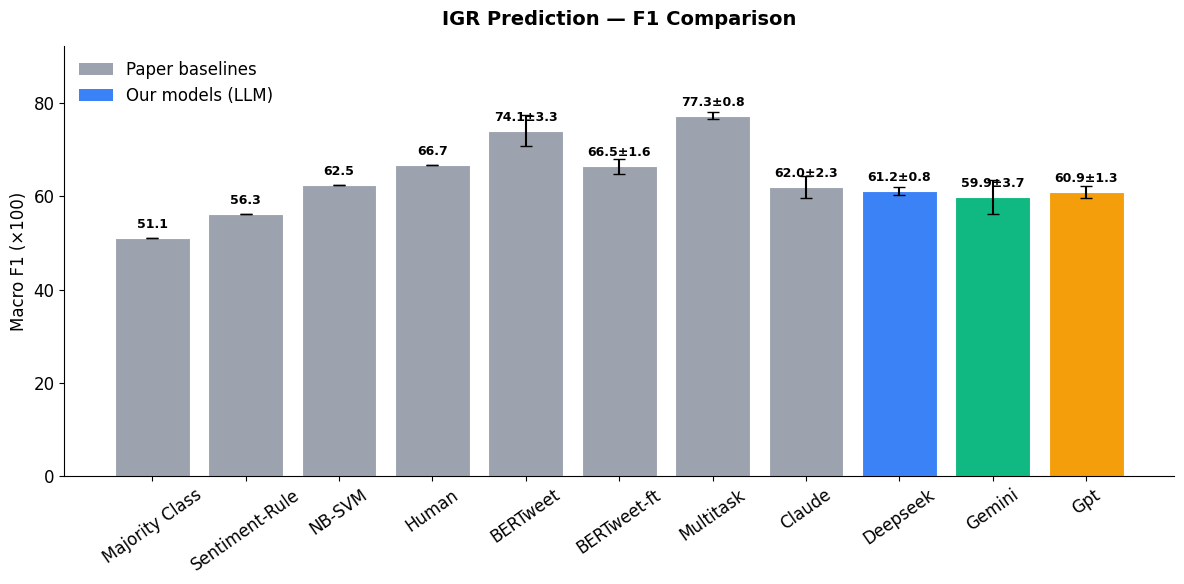

In [9]:
# =====================================================================
# CELL 2: Grouped bar chart — IGR F1 comparison
# =====================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Combine paper + ours for IGR
igr_data = {}
for name, vals in paper_baselines.items():
    if vals["igr"][0] is not None:
        igr_data[name] = vals["igr"]
for name, vals in our_models.items():
    igr_data[name] = vals["igr"]

names = list(igr_data.keys())
means = [igr_data[n][0] for n in names]
sds   = [igr_data[n][1] if igr_data[n][1] is not None else 0 for n in names]

# Color: paper models grey, ours colored
n_paper = len(paper_baselines)
n_ours  = len(our_models)
colors  = ["#9CA3AF"] * n_paper + ["#3B82F6", "#10B981", "#F59E0B", "#EF4444"][:n_ours]

bars = ax.bar(names, means, yerr=sds, capsize=4, color=colors, edgecolor="white", linewidth=0.8)

# Value labels on bars
for bar, m, s in zip(bars, means, sds):
    label = f"{m:.1f}" if s == 0 else f"{m:.1f}±{s:.1f}"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            label, ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("Macro F1 (×100)")
ax.set_title("IGR Prediction — F1 Comparison", fontsize=14, fontweight="bold", pad=15)
ax.set_ylim(0, max(means) + 15)
ax.tick_params(axis="x", rotation=35)

# Legend
from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(facecolor="#9CA3AF", label="Paper baselines"),
             Patch(facecolor="#3B82F6", label="Our models (LLM)")],
    loc="upper left", frameon=False
)

plt.tight_layout()
plt.savefig("igr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear', 'Surprise'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear', 'Surprise'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear', 'Surprise'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear', 'Surprise'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Fear', 'Surprise'] will be ignored
  warnings.warn(
/Users/chrisro/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_label.py:909:

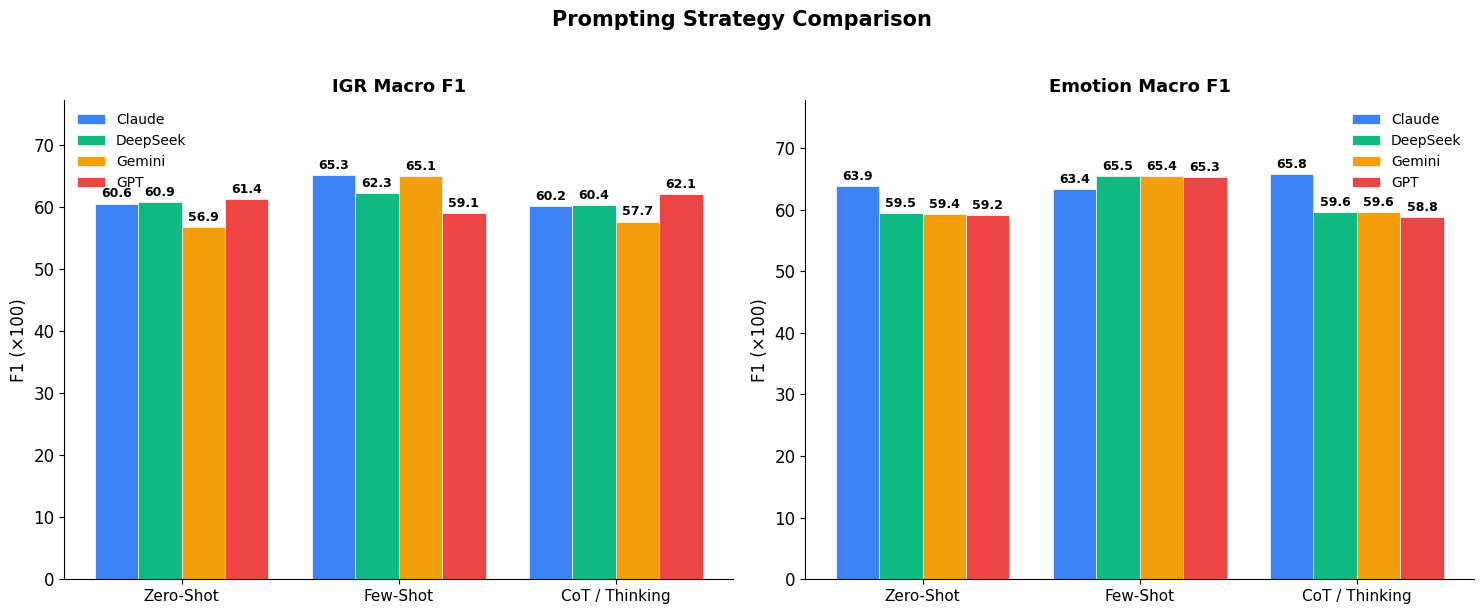

In [13]:
strategies = ["zero_shot", "few_shot", "cot_thinking"]
strategy_labels = ["Zero-Shot", "Few-Shot", "CoT / Thinking"]

model_dirs = {
    "Claude":   "../claude_label",
    "DeepSeek": "../deepseek_label",
    "Gemini":   "../gemini_label",
    "GPT":    "../gpt_label",       # uncomment when ready
}

# Evaluate each model x strategy individually
igr_scores = {m: [] for m in model_dirs}
emo_scores = {m: [] for m in model_dirs}

for model_name, dirpath in model_dirs.items():
    for strat in strategies:
        csv_path = f"{dirpath}/predictions_{strat}.csv"
        try:
            r = evaluate_single(csv_path)
            igr_scores[model_name].append(r["igr_f1_macro"] * 100)
            emo_scores[model_name].append(r["emotion_f1_macro"] * 100)
        except Exception as e:
            print(f"  ⚠️ {model_name}/{strat}: {e}")
            igr_scores[model_name].append(0.0)
            emo_scores[model_name].append(0.0)

# ── Plot: side-by-side IGR and Emotion ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(strategies))
n_models = len(model_dirs)
width = 0.8 / n_models
model_colors = ["#3B82F6", "#10B981", "#F59E0B", "#EF4444"][:n_models]

for ax, scores, title in zip(axes, [igr_scores, emo_scores], ["IGR Macro F1", "Emotion Macro F1"]):
    for i, (model_name, vals) in enumerate(scores.items()):
        offset = (i - n_models / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=model_name,
                       color=model_colors[i], edgecolor="white", linewidth=0.5)

        # Value labels
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f"{v:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(strategy_labels, fontsize=11)
    ax.set_ylabel("F1 (×100)")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, max(max(v) for v in scores.values()) + 12)
    ax.legend(frameon=False, fontsize=10)

fig.suptitle("Prompting Strategy Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

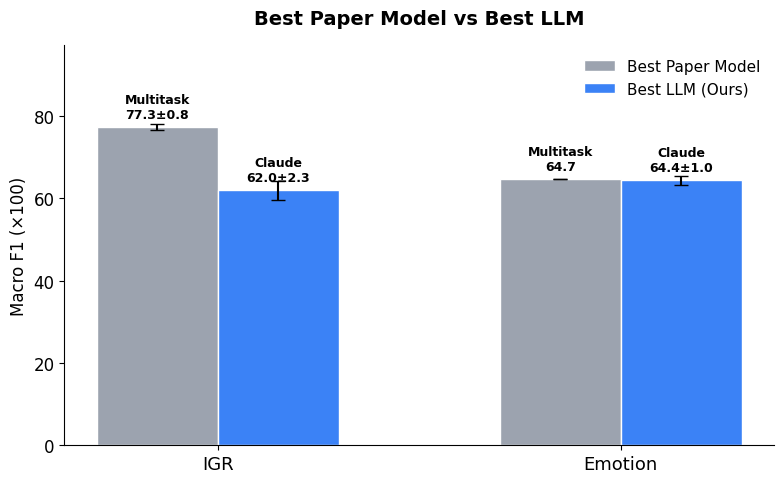

In [11]:
# =====================================================================
# CELL: Best Paper vs Best LLM — IGR & Emotion F1
# =====================================================================

fig, ax = plt.subplots(figsize=(8, 5))

# Best from paper
best_paper_igr = max((v["igr"] for v in paper_baselines.values() if v["igr"][0] is not None), key=lambda x: x[0])
best_paper_emo = max((v["emo"] for v in paper_baselines.values() if v["emo"][0] is not None), key=lambda x: x[0])

# Best from our LLMs
best_llm_igr = max((v["igr"] for v in our_models.values()), key=lambda x: x[0])
best_llm_emo = max((v["emo"] for v in our_models.values()), key=lambda x: x[0])

# Find names for labels
best_paper_igr_name = max((k for k, v in paper_baselines.items() if v["igr"][0] is not None), key=lambda k: paper_baselines[k]["igr"][0])
best_paper_emo_name = max((k for k, v in paper_baselines.items() if v["emo"][0] is not None), key=lambda k: paper_baselines[k]["emo"][0])
best_llm_igr_name   = max(our_models, key=lambda k: our_models[k]["igr"][0])
best_llm_emo_name   = max(our_models, key=lambda k: our_models[k]["emo"][0])

x = np.arange(2)
width = 0.3

paper_means = [best_paper_igr[0], best_paper_emo[0]]
paper_sds   = [best_paper_igr[1] or 0, best_paper_emo[1] or 0]
llm_means   = [best_llm_igr[0], best_llm_emo[0]]
llm_sds     = [best_llm_igr[1] or 0, best_llm_emo[1] or 0]

bars1 = ax.bar(x - width/2, paper_means, width, yerr=paper_sds, capsize=5,
               label="Best Paper Model", color="#9CA3AF", edgecolor="white")
bars2 = ax.bar(x + width/2, llm_means, width, yerr=llm_sds, capsize=5,
               label="Best LLM (Ours)", color="#3B82F6", edgecolor="white")

# Value labels with model names
for bar, m, s, name in zip(bars1, paper_means, paper_sds, [best_paper_igr_name, best_paper_emo_name]):
    label = f"{m:.1f}±{s:.1f}" if s else f"{m:.1f}"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{name}\n{label}", ha="center", va="bottom", fontsize=9, fontweight="bold")

for bar, m, s, name in zip(bars2, llm_means, llm_sds, [best_llm_igr_name, best_llm_emo_name]):
    label = f"{m:.1f}±{s:.1f}" if s else f"{m:.1f}"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{name}\n{label}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(["IGR", "Emotion"], fontsize=13)
ax.set_ylabel("Macro F1 (×100)")
ax.set_title("Best Paper Model vs Best LLM", fontsize=14, fontweight="bold", pad=15)
ax.set_ylim(0, max(paper_means + llm_means) + 20)
ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig("best_paper_vs_llm.png", dpi=150, bbox_inches="tight")
plt.show()

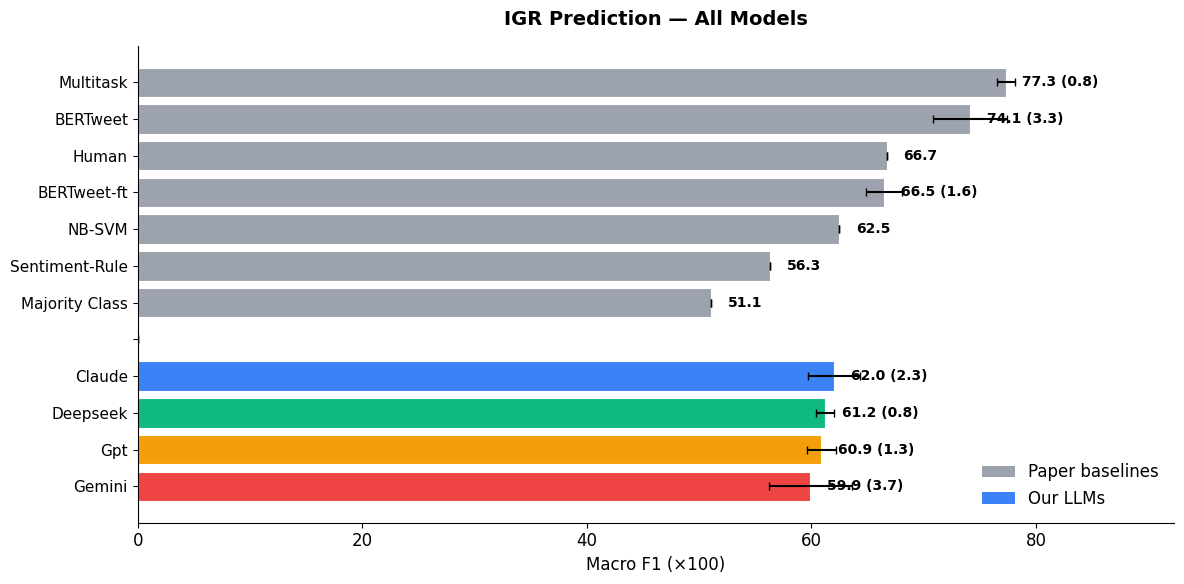

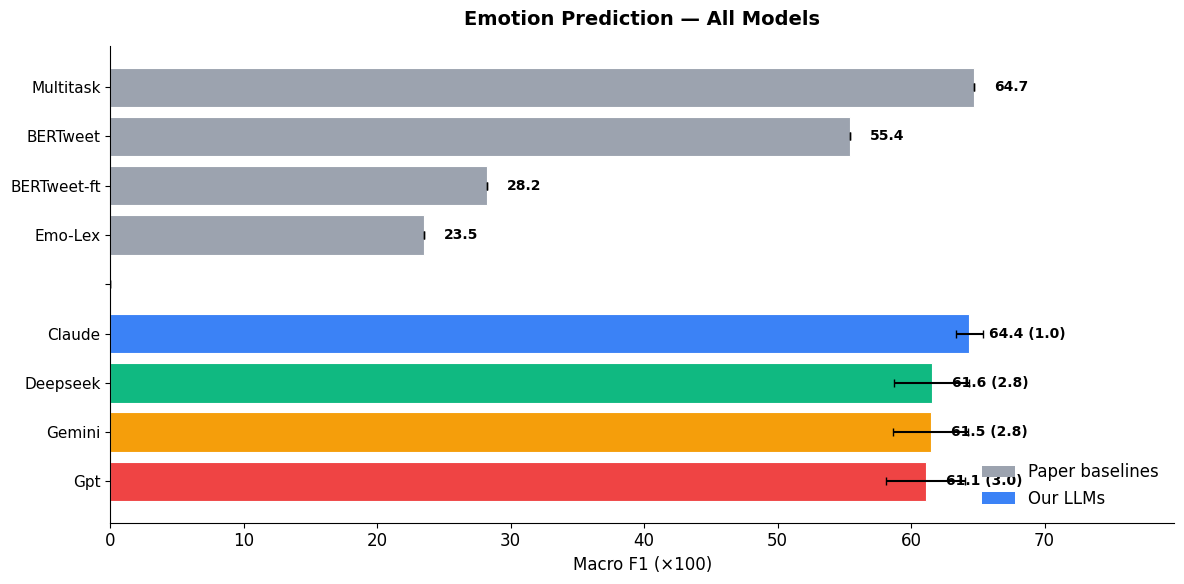

In [12]:
# =====================================================================
# CELL: All models compared — IGR breakdown
# =====================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Paper models with IGR scores
igr_paper = {k: v["igr"] for k, v in paper_baselines.items() if v["igr"][0] is not None}
igr_ours  = {k: v["igr"] for k, v in our_models.items()}

# Sort each group by score descending
paper_sorted = dict(sorted(igr_paper.items(), key=lambda x: x[1][0], reverse=True))
ours_sorted  = dict(sorted(igr_ours.items(),  key=lambda x: x[1][0], reverse=True))

names = list(paper_sorted.keys()) + [""] + list(ours_sorted.keys())  # gap between groups
means = [paper_sorted[n][0] for n in paper_sorted] + [0] + [ours_sorted[n][0] for n in ours_sorted]
sds   = [paper_sorted[n][1] or 0 for n in paper_sorted] + [0] + [ours_sorted[n][1] or 0 for n in ours_sorted]
colors = ["#9CA3AF"] * len(paper_sorted) + ["white"] + ["#3B82F6", "#10B981", "#F59E0B", "#EF4444"][:len(ours_sorted)]

bars = ax.barh(range(len(names)), means, xerr=sds, capsize=3, color=colors, edgecolor="white", linewidth=0.8)

for i, (bar, m, s) in enumerate(zip(bars, means, sds)):
    if m > 0:
        label = f"{m:.1f} ({s:.1f})" if s else f"{m:.1f}"
        ax.text(m + 1.5, bar.get_y() + bar.get_height()/2, label,
                va="center", fontsize=10, fontweight="bold")

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=11)
ax.set_xlabel("Macro F1 (×100)")
ax.set_title("IGR Prediction — All Models", fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, max(means) + 15)
ax.invert_yaxis()

ax.legend(
    handles=[Patch(facecolor="#9CA3AF", label="Paper baselines"),
             Patch(facecolor="#3B82F6", label="Our LLMs")],
    loc="lower right", frameon=False
)

plt.tight_layout()
plt.savefig("igr_all_models.png", dpi=150, bbox_inches="tight")
plt.show()


# =====================================================================
# CELL: All models compared — Emotion breakdown
# =====================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Paper models with emotion scores
emo_paper = {k: v["emo"] for k, v in paper_baselines.items() if v["emo"][0] is not None}
emo_ours  = {k: v["emo"] for k, v in our_models.items()}

paper_sorted = dict(sorted(emo_paper.items(), key=lambda x: x[1][0], reverse=True))
ours_sorted  = dict(sorted(emo_ours.items(),  key=lambda x: x[1][0], reverse=True))

names = list(paper_sorted.keys()) + [""] + list(ours_sorted.keys())
means = [paper_sorted[n][0] for n in paper_sorted] + [0] + [ours_sorted[n][0] for n in ours_sorted]
sds   = [paper_sorted[n][1] or 0 for n in paper_sorted] + [0] + [ours_sorted[n][1] or 0 for n in ours_sorted]
colors = ["#9CA3AF"] * len(paper_sorted) + ["white"] + ["#3B82F6", "#10B981", "#F59E0B", "#EF4444"][:len(ours_sorted)]

bars = ax.barh(range(len(names)), means, xerr=sds, capsize=3, color=colors, edgecolor="white", linewidth=0.8)

for i, (bar, m, s) in enumerate(zip(bars, means, sds)):
    if m > 0:
        label = f"{m:.1f} ({s:.1f})" if s else f"{m:.1f}"
        ax.text(m + 1.5, bar.get_y() + bar.get_height()/2, label,
                va="center", fontsize=10, fontweight="bold")

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=11)
ax.set_xlabel("Macro F1 (×100)")
ax.set_title("Emotion Prediction — All Models", fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, max(means) + 15)
ax.invert_yaxis()

ax.legend(
    handles=[Patch(facecolor="#9CA3AF", label="Paper baselines"),
             Patch(facecolor="#3B82F6", label="Our LLMs")],
    loc="lower right", frameon=False
)

plt.tight_layout()
plt.savefig("emotion_all_models.png", dpi=150, bbox_inches="tight")
plt.show()